In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

In [31]:
# Load splits saved by preprocessing notebook
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()  # squeeze to Series
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print('Training set shape:', X_train.shape)
print('Testing set shape: ', X_test.shape)
print('\nClass distribution in training:')
print(y_train.value_counts())

Training set shape: (239, 11)
Testing set shape:  (60, 11)

Class distribution in training:
DEATH_EVENT
0    162
1     77
Name: count, dtype: int64


In [32]:
# Re-apply StandardScaler (fit ONLY on training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Feature scaling applied using StandardScaler.')

Feature scaling applied using StandardScaler.


In [33]:
lr_model = LogisticRegression(
    class_weight='balanced',  # handles class imbalance
    max_iter=1000,            # enough iterations to converge
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)
print('Logistic Regression model trained.')

Logistic Regression model trained.


In [34]:
y_pred      = lr_model.predict(X_test_scaled)
y_pred_prob = lr_model.predict_proba(X_test_scaled)[:, 1]  # probability of class 1 (DEATH)

# --- Core Metrics ---
accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy : {accuracy:.4f}')
print(f'ROC-AUC  : {roc_auc:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Survived (0)', 'Died (1)']))

Accuracy : 0.7000
ROC-AUC  : 0.7343

Classification Report:
              precision    recall  f1-score   support

Survived (0)       0.78      0.78      0.78        41
    Died (1)       0.53      0.53      0.53        19

    accuracy                           0.70        60
   macro avg       0.65      0.65      0.65        60
weighted avg       0.70      0.70      0.70        60



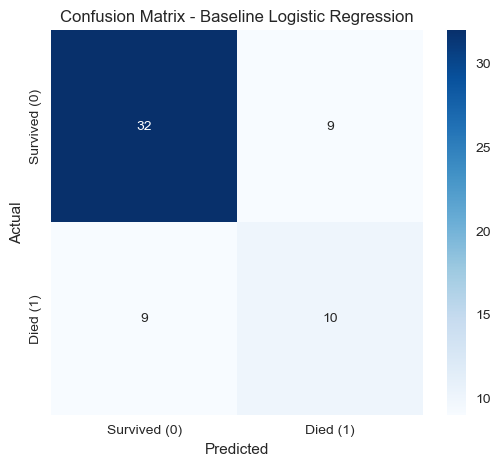

In [39]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Survived (0)', 'Died (1)'],
            yticklabels=['Survived (0)', 'Died (1)'])
plt.title('Confusion Matrix - Baseline Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



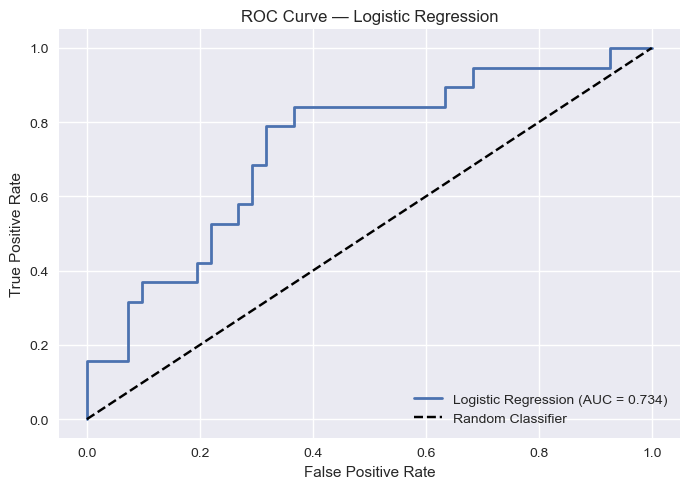

In [36]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [37]:
# Use scaled training data for CV
cv_scores_acc = cross_val_score(lr_model, X_train_scaled, y_train,
                                 cv=5, scoring='accuracy')
cv_scores_auc = cross_val_score(lr_model, X_train_scaled, y_train,
                                 cv=5, scoring='roc_auc')

print('5-Fold Cross-Validation Results (on training data):')
print(f'  Accuracy : {cv_scores_acc.mean():.4f} ± {cv_scores_acc.std():.4f}')
print(f'  ROC-AUC  : {cv_scores_auc.mean():.4f} ± {cv_scores_auc.std():.4f}')

5-Fold Cross-Validation Results (on training data):
  Accuracy : 0.7320 ± 0.0674
  ROC-AUC  : 0.7694 ± 0.0495


Feature Coefficients (sorted by magnitude):
                 Feature  Coefficient
        serum_creatinine     0.994974
       ejection_fraction    -0.760420
                     age     0.466574
creatinine_phosphokinase     0.329331
                 anaemia     0.327238
     high_blood_pressure     0.306994
                diabetes     0.273965
                 smoking     0.205902
            serum_sodium    -0.184602
               platelets    -0.127066
                     sex    -0.108327


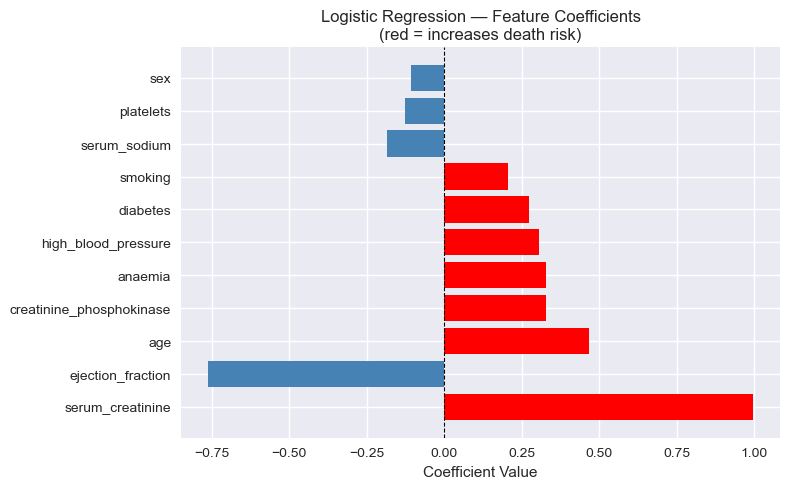

In [38]:
feature_names = X_train.columns.tolist()
coefficients  = lr_model.coef_[0]

coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', key=abs, ascending=False)

print('Feature Coefficients (sorted by magnitude):')
print(coef_df.to_string(index=False))

# Bar chart
plt.figure(figsize=(8, 5))
colors = ['red' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression — Feature Coefficients\n(red = increases death risk)')
plt.tight_layout()
plt.show()